# Transformer Multi-View Training
This notebook trains the Transformer model on the multi-view baseline keypoints dataset.

In [1]:
import pandas as pd
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [2]:
train_df = pd.read_csv("../Datasets/train_interpolated_multiview.csv")
val_df = pd.read_csv("../Datasets/val_interpolated_multiview.csv")
test_df = pd.read_csv("../Datasets/test_interpolated_multiview.csv")
PROC_DIR = "."
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Train samples: 71621
Validation samples: 15258
Test samples: 15294


In [3]:
le = LabelEncoder()
all_labels = pd.concat([train_df['label'], val_df['label'], test_df['label']])
le.fit(all_labels)
train_df['label'] = le.transform(train_df['label'])
val_df['label'] = le.transform(val_df['label'])
test_df['label'] = le.transform(test_df['label'])

In [4]:
# ---------------- Keypoint Augmentation Helpers ------------------
def random_scaling(x_seq, scale_range=(0.9, 1.1)):
    s = np.random.uniform(scale_range[0], scale_range[1])
    return x_seq * s

def random_rotation(x_seq, max_angle=10):
    theta = np.radians(np.random.uniform(-max_angle, max_angle))
    cos_val, sin_val = np.cos(theta), np.sin(theta)
    R = np.array([[cos_val, -sin_val, 0],
                  [sin_val, cos_val, 0],
                  [0, 0, 1]], dtype=np.float32)
    T = x_seq.shape[0]
    x_reshaped = x_seq.reshape(T, 129, 3)
    x_rotated = np.dot(x_reshaped, R.T)
    return x_rotated.reshape(T, -1)

def add_noise(x_seq, noise_level=0.01):
    noise = np.random.normal(0, noise_level, x_seq.shape)
    mask = (x_seq != 0.0)
    x_seq[mask] += noise[mask]
    return x_seq

def augment_sequence(x_seq):
    if np.random.rand() < 0.5:
        x_seq = random_scaling(x_seq)
    if np.random.rand() < 0.5:
        x_seq = random_rotation(x_seq)
    if np.random.rand() < 0.5:
        x_seq = add_noise(x_seq)
    return x_seq

# ---------------- Dataset Loader with Augmentation ------------------
class SignDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df
        self.augment = augment

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(f"{PROC_DIR}/{row.file}").astype(np.float32)
        
        if self.augment:
            x = augment_sequence(x)
            
        y = int(row.label)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.df)

In [5]:
train_loader = DataLoader(SignDataset(train_df, augment=True), batch_size=32, shuffle=True)
val_loader   = DataLoader(SignDataset(val_df, augment=False),   batch_size=32, shuffle=False)
test_loader  = DataLoader(SignDataset(test_df, augment=False),  batch_size=32, shuffle=False)

In [6]:
sample_batch_X, sample_batch_y = next(iter(train_loader))
input_dim = sample_batch_X.shape[-1]
num_classes = train_df.label.nunique()
print(f"Dynamically determined input_dim: {input_dim}")
print(f"Number of classes: {num_classes}")

Dynamically determined input_dim: 387
Number of classes: 401


In [7]:
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, filename='checkpoint.pt', save_dir='Models'):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.save_dir = save_dir
        self.path = os.path.join(save_dir, filename) 
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir, exist_ok=True)
            if self.verbose:
                print(f"Created directory: {self.save_dir}")

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [8]:
class TransformerSignModel(nn.Module):
    def __init__(self, input_dim=387, num_classes=401, d_model=256, nhead=8, num_layers=3, dropout=0.3):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU()
        )
        self.pos_encoder = nn.Parameter(torch.randn(1, 60, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        B, T, F = x.shape
        x = self.input_projection(x)
        x = x + self.pos_encoder[:, :T, :]
        x = self.transformer_encoder(x)
        x = torch.mean(x, dim=1)
        return self.fc(x)

In [9]:
trans_model = TransformerSignModel(input_dim=input_dim, num_classes=num_classes).to(device)
trans_loss_fn = nn.CrossEntropyLoss()
trans_optimizer = optim.Adam(trans_model.parameters(), lr=1e-4)
print(trans_model)

TransformerSignModel(
  (input_projection): Sequential(
    (0): Linear(in_features=387, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=256, out_features=401, bias=True)
)


In [10]:
EPOCHS = 150
trans_train_losses, trans_val_losses = [], []
trans_train_accs, trans_val_accs = [], []

trans_early_stopping = EarlyStopping(
    patience=7, 
    verbose=True,
    save_dir='../Models',
    filename='transformer_interpolated_multiview.pth'
)

for epoch in range(EPOCHS):
    trans_model.train()
    total_loss, correct = 0, 0

    for X, y in tqdm(train_loader, desc=f"Transformer Epoch {epoch+1}/{EPOCHS}"):
        X, y = X.to(device), y.to(device)

        trans_optimizer.zero_grad()
        preds = trans_model(X)
        loss = trans_loss_fn(preds, y)
        loss.backward()
        trans_optimizer.step()

        total_loss += loss.item()
        correct += (preds.argmax(1) == y).sum().item()

    trans_train_losses.append(total_loss)
    trans_train_accs.append(correct / len(train_df))

    # ---------------- Validation ----------------
    trans_model.eval()
    v_loss, v_correct = 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = trans_model(X)
            v_loss += trans_loss_fn(preds, y).item()
            v_correct += (preds.argmax(1) == y).sum().item()

    avg_val_loss = v_loss / len(val_loader) 
    trans_val_losses.append(avg_val_loss)
    trans_val_accs.append(v_correct / len(val_df))

    print(f"Epoch {epoch+1}: Train Loss={total_loss:.4f}, Val Loss={avg_val_loss:.4f}, Train Acc={trans_train_accs[-1]:.4f}, Val Acc={trans_val_accs[-1]:.4f}")

    trans_early_stopping(avg_val_loss, trans_model)

    if trans_early_stopping.early_stop:
        print("Early stopping triggered. Breaking training loop.")
        break

Transformer Epoch 1/150: 100%|██████████| 2239/2239 [11:44<00:00,  3.18it/s]


Epoch 1: Train Loss=11598.2075, Val Loss=4.1191, Train Acc=0.0422, Val Acc=0.1258
Validation loss decreased (inf --> 4.119137). Saving model...


Transformer Epoch 2/150: 100%|██████████| 2239/2239 [11:19<00:00,  3.29it/s]


Epoch 2: Train Loss=7875.2624, Val Loss=2.8767, Train Acc=0.2334, Val Acc=0.3207
Validation loss decreased (4.119137 --> 2.876711). Saving model...


Transformer Epoch 3/150: 100%|██████████| 2239/2239 [10:33<00:00,  3.53it/s]


...

Epoch 39: Train Loss=134.1163, Val Loss=0.5215, Train Acc=0.9825, Val Acc=0.8883
EarlyStopping counter: 5 of 7


Transformer Epoch 40/150: 100%|██████████| 2239/2239 [09:51<00:00,  3.79it/s]


Epoch 40: Train Loss=139.3070, Val Loss=0.4668, Train Acc=0.9815, Val Acc=0.9031
EarlyStopping counter: 6 of 7


Transformer Epoch 41/150: 100%|██████████| 2239/2239 [09:52<00:00,  3.78it/s]


Epoch 41: Train Loss=124.8884, Val Loss=0.5245, Train Acc=0.9835, Val Acc=0.8924
EarlyStopping counter: 7 of 7
Early stopping triggered. Breaking training loop.


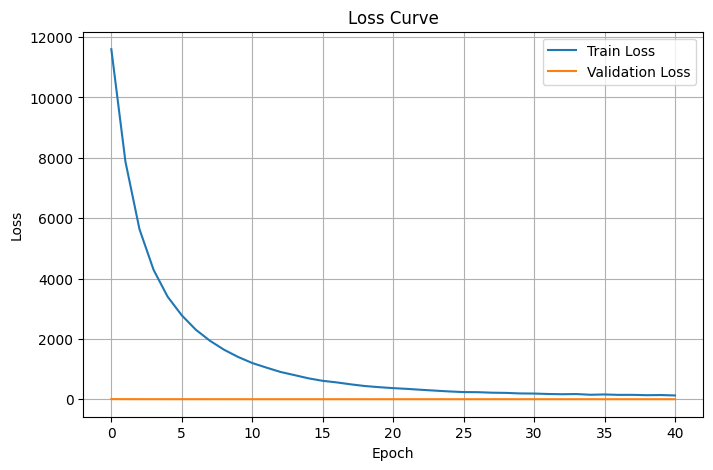

In [11]:
# -------- Plot Training vs Validation Loss ------------
plt.figure(figsize=(8,5))
plt.plot(trans_train_losses, label="Train Loss")
plt.plot(trans_val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

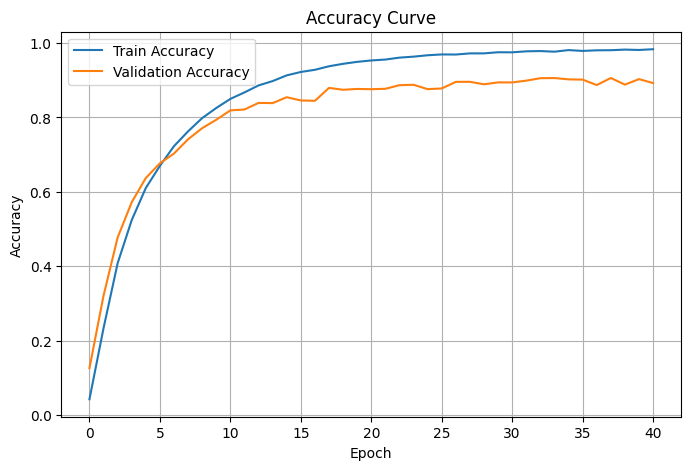

In [12]:
# -------- Plot Training vs Validation Accuracy ------------
plt.figure(figsize=(8,5))
plt.plot(trans_train_accs, label="Train Accuracy")
plt.plot(trans_val_accs, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()